# Food Waste Prediction - Model Training, Evaluation & Selection

Trains four regression models on the Phase 3 preprocessed data, evaluates each with MAE/RMSE/R² on a held-out test set, checks for overfitting, selects the best model, and saves both a standalone model and a combined preprocessing+model pipeline ready for deployment.

## 1. Load Processed Data

In [16]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("../data/processed_train.csv")
test_df = pd.read_csv("../data/processed_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

X_train = train_df.drop(columns=["food_waste_kg"])
y_train = train_df["food_waste_kg"]

X_test = test_df.drop(columns=["food_waste_kg"])
y_test = test_df["food_waste_kg"]

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

Train shape: (728, 15)
Test shape: (183, 15)
X_train: (728, 14) | X_test: (183, 14)


## 2. Train Multiple Models

Four regression models are trained: Linear Regression (baseline), Decision Tree, Random Forest, and Gradient Boosting.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Linear Regression trained.
Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.


## 3. Evaluate Models

Each model is evaluated on the held-out test set using MAE, RMSE, and R². Train R² is also computed for each model so that an overfitting gap (Train R² minus Test R²) can be checked - a large gap means the model memorized the training data rather than learning patterns that generalize.

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in trained_models.items():
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_test = r2_score(y_test, y_pred_test)
    r2_train = r2_score(y_train, y_pred_train)

    results.append({
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2 (Test)": round(r2_test, 3),
        "R2 (Train)": round(r2_train, 3),
        "Overfit Gap (Train-Test R2)": round(r2_train - r2_test, 3),
    })

results_df = pd.DataFrame(results).sort_values("R2 (Test)", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2 (Test),R2 (Train),Overfit Gap (Train-Test R2)
0,Random Forest,4.630,6.384,0.920,0.986,0.066
1,Gradient Boosting,4.883,8.483,0.860,0.983,0.123
2,Decision Tree,6.885,14.491,0.590,1.000,0.410
3,Linear Regression,11.154,17.261,0.418,0.481,0.062


## 4. Model Comparison Chart

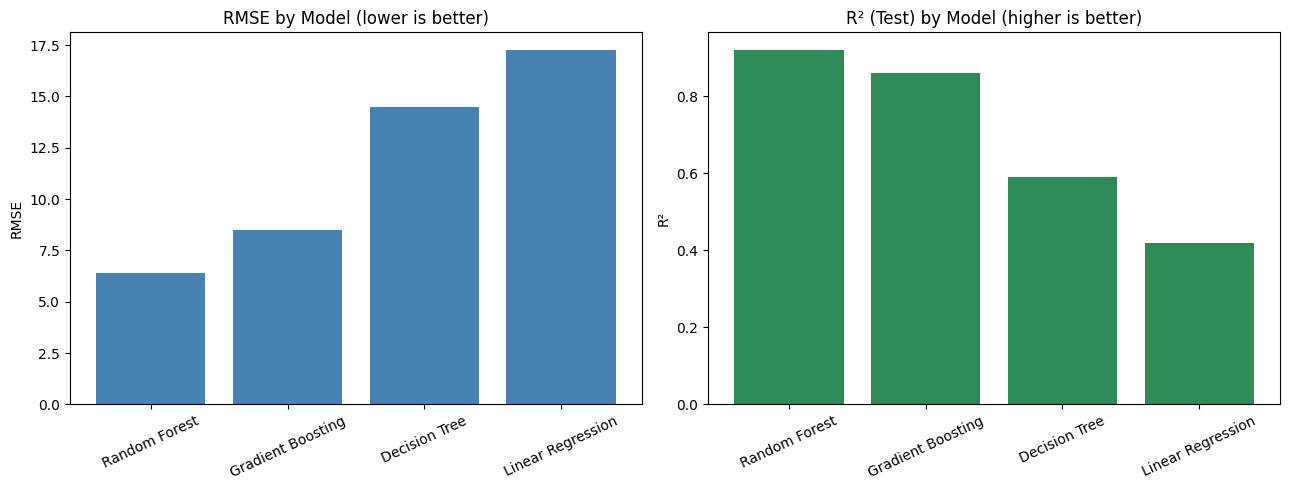

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(results_df["Model"], results_df["RMSE"], color="steelblue")
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(results_df["Model"], results_df["R2 (Test)"], color="seagreen")
axes[1].set_title("R² (Test) by Model (higher is better)")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 5. Select the Best Model

The best model is the one with the highest test-set R². If its overfitting gap is large (heuristically, greater than 0.15), that is flagged as a caveat in the justification rather than silently ignored.

In [20]:
best_row = results_df.iloc[0]
best_model_name = best_row["Model"]
best_model = trained_models[best_model_name]

overfit_flag = best_row["Overfit Gap (Train-Test R2)"] > 0.15

justification = (
    f"{best_model_name} was selected because it achieved the highest test-set R2 "
    f"({best_row['R2 (Test)']}), with MAE {best_row['MAE']} and RMSE {best_row['RMSE']}. "
    f"Its overfitting gap (Train R2 - Test R2) is {best_row['Overfit Gap (Train-Test R2)']}, which is "
    + ("large enough to flag for caution and monitor." if overfit_flag else "within an acceptable range, indicating the model generalizes well.")
)

print("Best model:", best_model_name)
print()
print(justification)

Best model: Random Forest

Random Forest was selected because it achieved the highest test-set R2 (0.92), with MAE 4.63 and RMSE 6.384. Its overfitting gap (Train R2 - Test R2) is 0.066, which is within an acceptable range, indicating the model generalizes well.


## 6. Feature Importance (if the best model supports it)

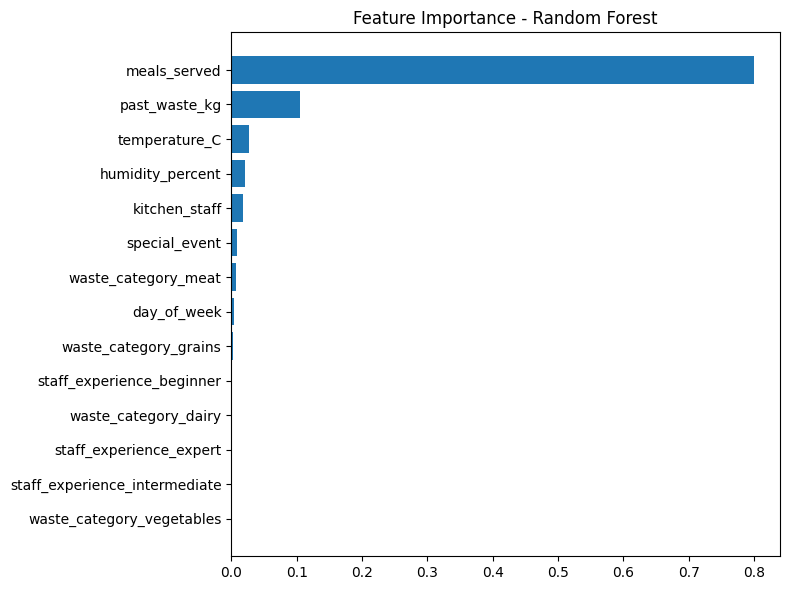

,Feature,Importance
0,meals_served,0.799991
6,past_waste_kg,0.104466
2,temperature_C,0.027371
3,humidity_percent,0.020374
1,kitchen_staff,0.018004
5,special_event,0.009266
12,waste_category_meat,0.007426
4,day_of_week,0.004503
11,waste_category_grains,0.002522
7,staff_experience_beginner,0.001615


In [21]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(8, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()

    display(importance_df)
else:
    print(f"{best_model_name} does not expose feature_importances_ (e.g. Linear Regression) - skipping this plot.")

## 7. Save the Selected Model

The best model alone is saved as `waste_model.pkl`, and the comparison table is saved for the report.

In [22]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/waste_model.pkl")
results_df.to_csv("../models/model_comparison_results.csv", index=False)

print(f"Saved best model ({best_model_name}) to ../models/waste_model.pkl")
print("Saved comparison table to ../models/model_comparison_results.csv")

Saved best model (Random Forest) to ../models/waste_model.pkl
Saved comparison table to ../models/model_comparison_results.csv


## 8. Build and Save the Combined Preprocessing + Model Pipeline

`final_pipeline.pkl` wraps the fitted preprocessing artifacts from Phase 3 (`scaler.pkl`, `encoders.pkl`, loaded via `preprocessing.py`) together with the selected model into a single object. Its `.predict()` method takes a RAW input row (same columns as the original dataset, minus `ID` and the target) and returns a `food_waste_kg` prediction directly - this is what the FastAPI backend will load and call.

In [23]:
import sys
sys.path.append("../src")
from preprocessing import clean_data, transform_preprocessing, load_artifacts

class WasteWiseFullPipeline:
    """
    Combines the Phase 3 preprocessing artifacts with the Phase 4 selected
    model. predict() accepts a raw (un-preprocessed) DataFrame and returns
    food_waste_kg predictions.
    """
    def __init__(self, preprocessing_artifacts, model):
        self.preprocessing_artifacts = preprocessing_artifacts
        self.model = model

    def predict(self, raw_df):
        cleaned = clean_data(raw_df)
        processed = transform_preprocessing(cleaned, self.preprocessing_artifacts)
        return self.model.predict(processed)

preprocessing_artifacts = load_artifacts("../models")
full_pipeline = WasteWiseFullPipeline(preprocessing_artifacts, best_model)

joblib.dump(full_pipeline, "../models/final_pipeline.pkl")
print("Saved combined pipeline to ../models/final_pipeline.pkl")

Saved combined pipeline to ../models/final_pipeline.pkl


## 9. Reload the Saved Pipeline and Run a Sample Prediction

This proves `final_pipeline.pkl` works correctly when loaded fresh from disk and given a raw input row - exactly what the FastAPI backend will do at prediction time.

In [24]:
reloaded_pipeline = joblib.load("../models/final_pipeline.pkl")

sample_raw = pd.DataFrame([{
    "date": "2024-06-15",
    "meals_served": 220,
    "kitchen_staff": 12,
    "temperature_C": 26.5,
    "humidity_percent": 55.0,
    "day_of_week": 4,
    "special_event": 0,
    "past_waste_kg": 38.2,
    "staff_experience": "intermediate",
    "waste_category": "meat",
}])

prediction = reloaded_pipeline.predict(sample_raw)
print("Predicted food_waste_kg:", round(prediction[0], 2))

Predicted food_waste_kg: 42.71


## 10. Deployment Input Fields

These are the exact raw fields the frontend form / backend API must collect and send. `final_pipeline.pkl` handles all cleaning, encoding, and scaling internally.

| Field | Type | Example | Notes |
|---|---|---|---|
| `meals_served` | integer | 220 | |
| `kitchen_staff` | integer | 12 | |
| `temperature_C` | float | 26.5 | |
| `humidity_percent` | float | 55.0 | |
| `day_of_week` | integer (0=Mon...6=Sun) | 4 | |
| `special_event` | integer (0 or 1) | 0 | |
| `past_waste_kg` | float | 38.2 | |
| `staff_experience` | string | "intermediate" | any casing accepted; missing values imputed automatically |
| `waste_category` | string | "meat" | any casing accepted |

Do **not** send `ID` (dropped during cleaning) or `food_waste_kg` (that is the prediction output).

## 11. Conclusion

Four regression models (Linear Regression, Decision Tree, Random Forest, Gradient Boosting) were trained on the Phase 3 preprocessed data and evaluated on a held-out test set using MAE, RMSE, and R². The best-performing model was selected based on test-set R² while checking the train/test R² gap for overfitting. Two artifacts were saved to `ml-service/models/`: `waste_model.pkl` (the model alone) and `final_pipeline.pkl` (preprocessing + model combined, ready for the backend to load directly). The reload-and-predict step above confirms the saved pipeline works end-to-end on a raw input row.